# Laboratorio 5. Clasificación de tweets usando minería de texto

## Análisis exploratorio, modelos de clasificación y análisis de sentimiento

CC3084 Data Science. Universidad del Valle de Guatemala. Semestre II 2026.

Dataset: [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/c/nlp-getting-started), de Kaggle.

---
# 0. Configuración y descarga de datos

In [24]:
import os, re, string, warnings, json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_DIR = Path("data")
FIG_DIR  = Path("figuras")
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

def guardar_fig(nombre):
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{nombre}.png", dpi=150, bbox_inches="tight")

print("Entorno listo")

Entorno listo


## 0.1 Descarga del train.csv

1. Entrar a <https://www.kaggle.com/c/nlp-getting-started> y aceptar las reglas de la competencia, porque de lo contrario la API responde 403.
2. En Kaggle ir a Settings, luego API y luego Create New Token, que descarga el archivo kaggle.json.
3. Colocar kaggle.json en ~/.kaggle en Linux o Mac, o en C:\Users\usuario\.kaggle en Windows.

La celda de abajo intenta en orden usar el archivo si ya está en la carpeta data, descargarlo con kagglehub y descargarlo con la CLI de kaggle. Si las tres fallan, basta con dejar train.csv dentro de la carpeta data.

In [25]:
def obtener_datos(destino=DATA_DIR / "train.csv"):
    destino = Path(destino)
    if destino.exists():
        print(f"OK: ya existe {destino}")
        return destino

    try:
        import kagglehub, shutil
        ruta = kagglehub.competition_download("nlp-getting-started")
        for f in Path(ruta).rglob("train.csv"):
            shutil.copy(f, destino)
            print(f"OK: descargado con kagglehub -> {destino}")
            return destino
    except Exception as e:
        print(f"kagglehub no funcionó ({type(e).__name__}: {e})")

    try:
        import subprocess, zipfile
        subprocess.run(
            ["kaggle", "competitions", "download", "-c", "nlp-getting-started",
             "-p", str(DATA_DIR)], check=True)
        zip_path = DATA_DIR / "nlp-getting-started.zip"
        with zipfile.ZipFile(zip_path) as z:
            z.extractall(DATA_DIR)
        print(f"OK: descargado con la CLI de kaggle -> {destino}")
        return destino
    except Exception as e:
        print(f"CLI de kaggle no funcionó ({type(e).__name__}: {e})")

    raise FileNotFoundError(
        "No se pudo descargar automáticamente.\n"
        "Plan B (30 segundos): bajen train.csv de\n"
        "  https://www.kaggle.com/c/nlp-getting-started/data\n"
        f"y déjenlo en: {destino.resolve()}"
    )

ruta_train = obtener_datos()

OK: ya existe data\train.csv


In [26]:
df = pd.read_csv(ruta_train)
print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")
df.head()

Filas: 7613  |  Columnas: 5


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1


---
# 1. Análisis exploratorio

Revisamos la estructura del dataset, los valores faltantes y la relación de cada variable disponible con la etiqueta de desastre real.

In [27]:
print(df.info())
print("\nDuplicados exactos de texto:", df.duplicated(subset=["text"]).sum())

faltantes = pd.DataFrame({
    "n_faltantes": df.isna().sum(),
    "pct_faltantes": (df.isna().mean() * 100).round(2)
})
faltantes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB
None

Duplicados exactos de texto: 110


,n_faltantes,pct_faltantes
id,0,0.00
keyword,61,0.80
location,2533,33.27
text,0,0.00
target,0,0.00


target
0    4342
1    3271
Name: count, dtype: int64

Proporciones:
 target
0    0.5703
1    0.4297
Name: count, dtype: float64


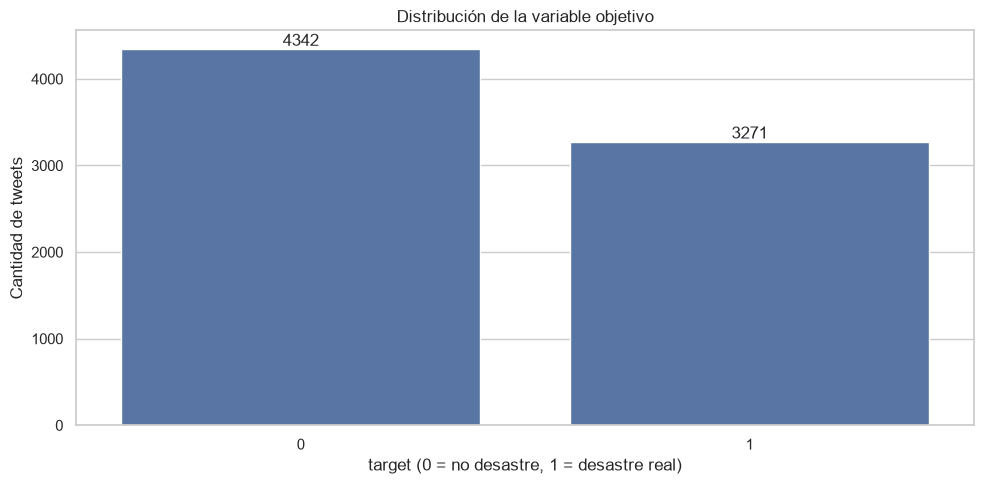

In [28]:
conteo = df["target"].value_counts().sort_index()
print(conteo)
print("\nProporciones:\n", (conteo / len(df)).round(4))

ax = sns.countplot(data=df, x="target")
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("target (0 = no desastre, 1 = desastre real)")
ax.set_ylabel("Cantidad de tweets")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
guardar_fig("01_distribucion_target")
plt.show()

El dataset tiene 7,613 tweets: 4,342 no son desastre real y 3,271 sí, un 57 contra 43 por ciento. El desbalance es leve pero fija el piso del problema, porque predecir siempre la clase mayoritaria acierta el 57 por ciento de las veces y cualquier modelo tiene que superar ese valor.

In [29]:
contradictorios = (df.groupby("text")["target"]
                    .agg(["nunique", "count", "mean"])
                    .query("nunique > 1")
                    .sort_values("count", ascending=False))
print(f"Textos repetidos con etiqueta contradictoria: {len(contradictorios)}")
contradictorios.head(10)

Textos repetidos con etiqueta contradictoria: 18


,nunique,count,mean
text,,,
The Prophet (peace be upon him) said 'Save yourself from Hellfire even if it is by giving half a date in charity.',2,6,0.333333
He came to a land which was engulfed in tribal war and turned it into a land of peace i.e. Madinah. #ProphetMuhammad #islam,2,6,0.333333
that horrible sinking feeling when youÛªve been at home on your phone for a while and you realise its been on 3G this whole time,2,4,0.500000
.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https://t.co/rqWuoy1fm4,2,4,0.750000
To fight bioterrorism sir.,2,4,0.500000
#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect,2,3,0.333333
#foodscare #offers2go #NestleIndia slips into loss after #Magginoodle #ban unsafe and hazardous for #humanconsumption,2,3,0.666667
Who is bringing the tornadoes and floods. Who is bringing the climate change. God is after America He is plaguing her\n \n#FARRAKHAN #QUOTE,2,3,0.333333
CLEARED:incident with injury:I-495 inner loop Exit 31 - MD 97/Georgia Ave Silver Spring,2,3,0.666667


Hay 18 textos repetidos con etiquetas distintas, es decir el mismo tweet catalogado una vez como desastre real y otra como no. Son pocos frente a 7,613 filas, pero son ruido de etiquetado que pone un techo al accuracy alcanzable. No los eliminamos porque no hay forma objetiva de decidir cuál etiqueta es la correcta.

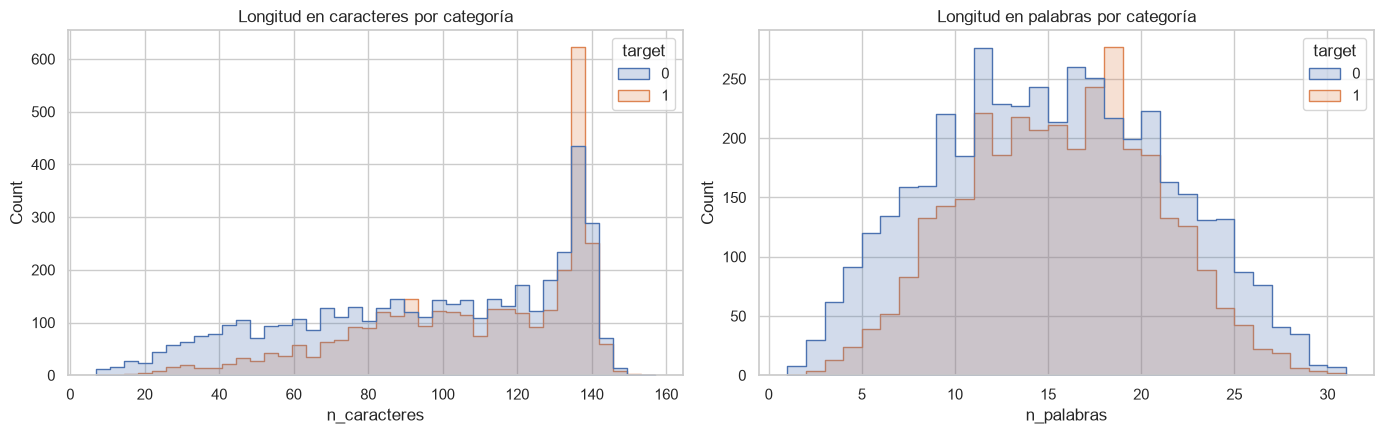

target                        0            1
n_caracteres count  4342.000000  3271.000000
             mean     95.706817   108.113421
             std      35.885924    29.309854
             min       7.000000    14.000000
             25%      68.000000    88.000000
             50%     101.000000   115.000000
             75%     130.000000   136.000000
             max     157.000000   151.000000
n_palabras   count  4342.000000  3271.000000
             mean     14.704744    15.167533
             std       6.161564     5.096806
             min       1.000000     2.000000
             25%      10.000000    11.000000
             50%      15.000000    15.000000
             75%      19.000000    19.000000
             max      31.000000    30.000000

In [30]:
df["n_caracteres"] = df["text"].str.len()
df["n_palabras"]   = df["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(data=df, x="n_caracteres", hue="target", bins=40, ax=axes[0], element="step")
axes[0].set_title("Longitud en caracteres por categoría")
sns.histplot(data=df, x="n_palabras", hue="target", bins=30, ax=axes[1], element="step")
axes[1].set_title("Longitud en palabras por categoría")
guardar_fig("02_longitudes")
plt.show()

df.groupby("target")[["n_caracteres", "n_palabras"]].describe().T

Los tweets de desastre real son más largos: 108 caracteres contra 96, y 15.2 palabras contra 14.7. La diferencia es consistente pero moderada, así que agregamos el número de palabras como variable candidata sin esperar que resuelva el problema por sí sola.

target               0       1
tiene_url       0.4143  0.6640
n_menciones     0.4203  0.2721
n_hashtags      0.3888  0.5020
tiene_numero    0.4963  0.7245
menciona_911    0.0002  0.0009
pct_mayusculas  0.0980  0.1019


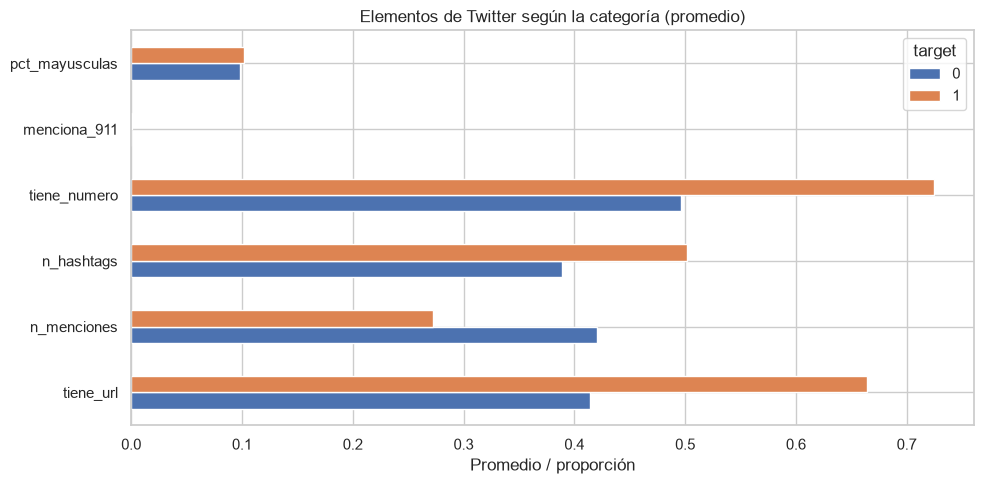

In [31]:
df["tiene_url"]      = df["text"].str.contains(r"http\S+", regex=True).astype(int)
df["n_menciones"]    = df["text"].str.count(r"@\w+")
df["n_hashtags"]     = df["text"].str.count(r"#\w+")
df["tiene_numero"]   = df["text"].str.contains(r"\d", regex=True).astype(int)
df["menciona_911"]   = df["text"].str.contains(r"\b911\b", regex=True).astype(int)
df["pct_mayusculas"] = df["text"].apply(lambda t: sum(c.isupper() for c in t) / max(len(t), 1))

resumen = df.groupby("target")[["tiene_url", "n_menciones", "n_hashtags",
                                "tiene_numero", "menciona_911", "pct_mayusculas"]].mean().round(4)
print(resumen.T)

ax = resumen.T.plot(kind="barh")
ax.set_title("Elementos de Twitter según la categoría (promedio)")
ax.set_xlabel("Promedio / proporción")
ax.legend(title="target")
guardar_fig("03_elementos_twitter")
plt.show()

Las URLs aparecen en el 66 por ciento de los tweets de desastre real contra el 41 por ciento de los demás, porque suelen enlazar una noticia, y por eso guardamos esa marca antes de eliminarlas del texto. Los tweets de desastre real también traen más números, 72 contra 50 por ciento, y más hashtags, 50 contra 39, mientras que las menciones a otro usuario son más comunes en los que no son desastre, 42 contra 27 por ciento.

La palabra 911 resultó anecdótica, ya que aparece en 4 tweets de 7,613, así que no recibe tratamiento especial más allá de conservarla como token propio.

Keywords distintas: 221
Tweets sin keyword: 61


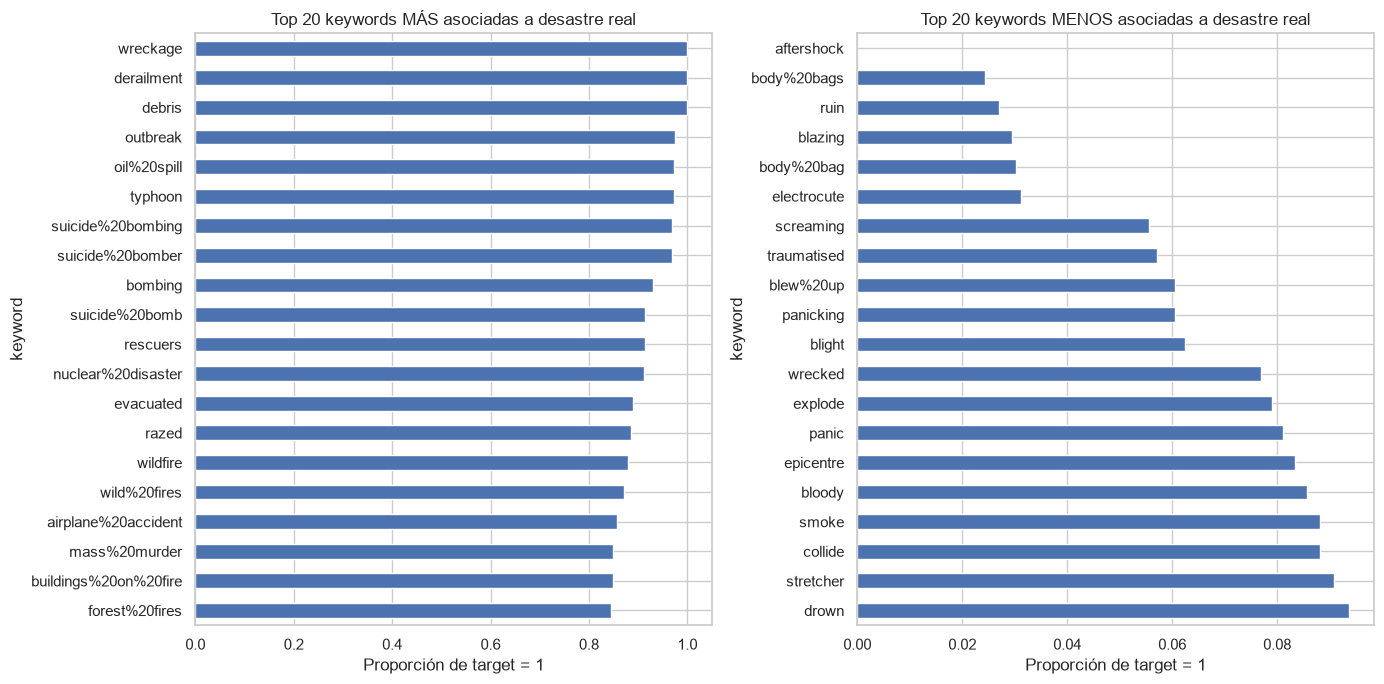

In [32]:
print("Keywords distintas:", df["keyword"].nunique())
print("Tweets sin keyword:", df["keyword"].isna().sum())

kw = (df.dropna(subset=["keyword"])
        .groupby("keyword")["target"]
        .agg(["count", "mean"])
        .rename(columns={"count": "n_tweets", "mean": "prop_desastre"}))

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
kw.nlargest(20, "prop_desastre").sort_values("prop_desastre").plot(
    kind="barh", y="prop_desastre", ax=axes[0], legend=False)
axes[0].set_title("Top 20 keywords MÁS asociadas a desastre real")
axes[0].set_xlabel("Proporción de target = 1")

kw.nsmallest(20, "prop_desastre").sort_values("prop_desastre", ascending=False).plot(
    kind="barh", y="prop_desastre", ax=axes[1], legend=False)
axes[1].set_title("Top 20 keywords MENOS asociadas a desastre real")
axes[1].set_xlabel("Proporción de target = 1")
guardar_fig("04_keywords_vs_target")
plt.show()

El dataset trae 221 keywords distintas y solo 61 tweets sin keyword. Es la variable individual más informativa: debris, derailment y wreckage son prácticamente deterministas con 100 por ciento de desastre real, igual que outbreak, oil spill y typhoon por encima del 97 por ciento, mientras que aftershock, body bags, ruin y blazing quedan por debajo del 3 por ciento.

También hay keywords genuinamente ambiguas como bombed, explosion, hail, storm y hurricane, todas cerca del 50 por ciento, que es donde esperamos que el modelo falle más. Por eso usamos keyword como característica adicional del texto.

Locations distintas: 3341
Tweets sin location: 2533 (33.3%)


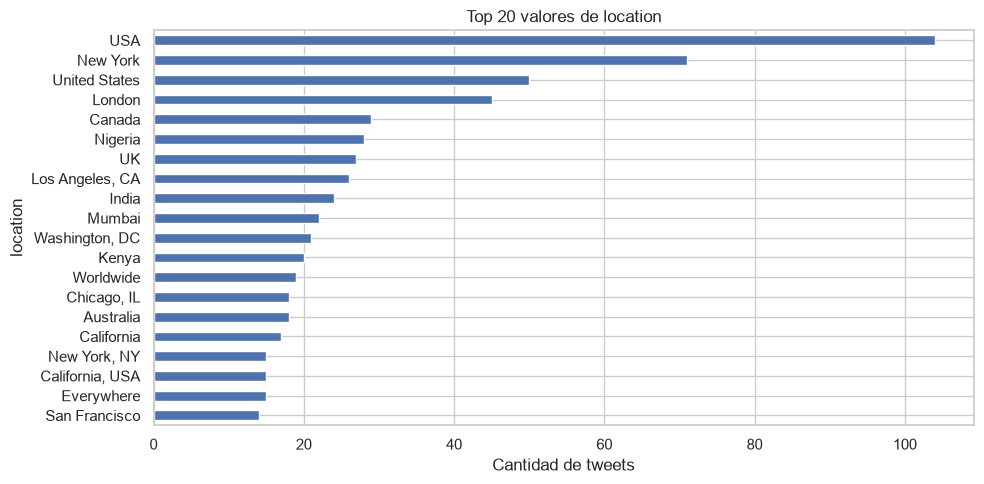

,count,prop_desastre
location,,
Mumbai,22,0.863636
India,24,0.833333
Nigeria,28,0.785714
"Washington, DC",21,0.714286
USA,104,0.644231
Worldwide,19,0.631579
UK,27,0.592593
United States,50,0.540000
"California, USA",15,0.533333


In [33]:
print("Locations distintas:", df["location"].nunique())
print("Tweets sin location:", df["location"].isna().sum(),
      f"({df['location'].isna().mean():.1%})")

top_loc = df["location"].value_counts().head(20)
ax = top_loc.sort_values().plot(kind="barh")
ax.set_title("Top 20 valores de location")
ax.set_xlabel("Cantidad de tweets")
guardar_fig("05_top_locations")
plt.show()

(df[df["location"].isin(top_loc.index)]
   .groupby("location")["target"].agg(["count", "mean"])
   .rename(columns={"mean": "prop_desastre"})
   .sort_values("prop_desastre", ascending=False))

Es texto libre sin validar: 3,341 valores distintos para 7,613 tweets y un tercio vacío. Entre los valores frecuentes hay ubicaciones reales mezcladas con cosas como Worldwide o Everywhere que no aportan información geográfica.

Al cruzar las locations más frecuentes con la proporción de desastre aparecen valores altos en Mumbai, India y Nigeria, pero con muestras de 15 a 30 tweets. Descartamos location del modelo por la alta cardinalidad, los nulos y el riesgo de sobreajustar a ubicaciones con pocos ejemplos.

In [34]:
df.to_csv(DATA_DIR / "train_eda.csv", index=False)
print("Guardado: data/train_eda.csv")

Guardado: data/train_eda.csv


---
# 2. Limpieza, preprocesamiento y n-gramas

Limpiamos y normalizamos el texto, y analizamos las palabras y n-gramas más frecuentes de cada categoría. Usamos re para expresiones regulares, nltk para stopwords y lematización con WordNet, emoji para detectar emoticones y wordcloud para las nubes de palabras.

In [35]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

for recurso in ["stopwords", "wordnet", "omw-1.4", "punkt"]:
    try:
        nltk.download(recurso, quiet=True)
    except Exception as e:
        print(f"No se pudo bajar {recurso}: {e}")

try:
    import emoji
    HAY_EMOJI = True
except ImportError:
    HAY_EMOJI = False
    print("Módulo 'emoji' no instalado: se usará un regex de respaldo.")

df = pd.read_csv(DATA_DIR / "train_eda.csv")
print(df.shape)

(7613, 13)


In [36]:
REGEX_EMOJI = re.compile(
    "[\U0001F300-\U0001F5FF\U0001F600-\U0001F64F\U0001F680-\U0001F6FF"
    "\U0001F900-\U0001F9FF☀-⛿✀-➿]", flags=re.UNICODE)

def extraer_emojis(texto):
    if HAY_EMOJI:
        return [c for c in texto if c in emoji.EMOJI_DATA]
    return REGEX_EMOJI.findall(texto)

df["emojis"]   = df["text"].apply(extraer_emojis)
df["n_emojis"] = df["emojis"].apply(len)

print(f"Tweets con al menos un emoji: {(df['n_emojis'] > 0).sum()} "
      f"({(df['n_emojis'] > 0).mean():.2%})")
print("\nEmojis más frecuentes:")
print(Counter([e for lista in df["emojis"] for e in lista]).most_common(15))
print("\nPromedio de emojis por categoría:")
print(df.groupby("target")["n_emojis"].mean())

df["n_emoticones_ascii"] = df["text"].str.count(r"[:;=][-^]?[)(DPp/\\|]")
print("\nTweets con emoticones ASCII (patrón crudo):", (df["n_emoticones_ascii"] > 0).sum())

Tweets con al menos un emoji: 10 (0.13%)

Emojis más frecuentes:
[('©', 10)]

Promedio de emojis por categoría:
target
0    0.000230
1    0.002751
Name: n_emojis, dtype: float64

Tweets con emoticones ASCII (patrón crudo): 4035


Solo 10 tweets tienen un emoji reconocido por la librería emoji, y en los diez casos es el símbolo de copyright. El patrón de emoticones ASCII dio 4,034 coincidencias, pero 3,964 eran la secuencia de dos puntos y barra de http, un falso positivo de la expresión regular, así que quedan 70 tweets con un emoticono genuino.

Con esa presencia el aporte a la clasificación es despreciable y los eliminamos en la limpieza. Para el análisis de sentimiento sí los conservamos más adelante, porque VADER les asigna valencia.

In [37]:
STOPWORDS = set(stopwords.words("english"))
STOPWORDS -= {"no", "not", "nor", "against", "up", "down", "out", "off"}
lematizador = WordNetLemmatizer()

MAPA_HTML = {"&amp;": " and ", "&lt;": " ", "&gt;": " ", "&quot;": " ", "&#39;": "'"}

def limpiar_texto(texto, lematizar=True, conservar_911=True):
    t = str(texto)

    for k, v in MAPA_HTML.items():
        t = t.replace(k, v)

    t = t.lower()

    t = re.sub(r"http\S+|www\.\S+", " ", t)

    t = re.sub(r"@\w+", " ", t)

    t = re.sub(r"#(\w+)", r"\1", t)

    t = REGEX_EMOJI.sub(" ", t)
    t = re.sub(r"[:;=][-^]?[)(dp/\\|]", " ", t)

    if conservar_911:
        t = re.sub(r"\b911\b", " numero911 ", t)
    t = re.sub(r"\d+", " ", t)

    t = t.translate(str.maketrans("", "", string.punctuation))
    t = re.sub(r"[^a-z\s]", " ", t)

    tokens = t.split()

    tokens = [w for w in tokens if w not in STOPWORDS and len(w) > 2]

    if lematizar:
        tokens = [lematizador.lemmatize(w) for w in tokens]

    return " ".join(tokens)

ejemplos = [
    "Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all",
    "@user OMG this is soooo funny :) http://t.co/abc123 &amp; more",
    "Call 911!!! There's a FIRE in the building #emergency",
]
for e in ejemplos:
    print(f"ANTES : {e}\nDESPUÉS: {limpiar_texto(e)}\n")

ANTES : Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
DESPUÉS: deed reason earthquake may allah forgive

ANTES : @user OMG this is soooo funny :) http://t.co/abc123 &amp; more
DESPUÉS: omg soooo funny

ANTES : Call 911!!! There's a FIRE in the building #emergency
DESPUÉS: call numero there fire building emergency



In [38]:
df["texto_limpio"] = df["text"].apply(limpiar_texto)

vacios = (df["texto_limpio"].str.strip() == "").sum()
print(f"Tweets vacíos después de limpiar: {vacios}")
if vacios:
    print(df.loc[df["texto_limpio"].str.strip() == "", "text"].head(10).tolist())

df["n_palabras_limpio"] = df["texto_limpio"].str.split().str.len()
print("\nPalabras antes vs. después:")
print(df[["n_palabras", "n_palabras_limpio"]].describe().round(2))

print("\nComparación en 5 tweets al azar:")
df.sample(5, random_state=RANDOM_STATE)[["text", "texto_limpio"]]

Tweets vacíos después de limpiar: 1
['@Truly_Stings Yo Dm me']

Palabras antes vs. después:
       n_palabras  n_palabras_limpio
count     7613.00            7613.00
mean        14.90               8.48
std          5.73               3.41
min          1.00               0.00
25%         11.00               6.00
50%         15.00               9.00
75%         19.00              11.00
max         31.00              21.00

Comparación en 5 tweets al azar:


,text,texto_limpio
2644,So you have a new weapon that can cause un-imaginable destruction.,new weapon cause unimaginable destruction
2227,The f$&amp;@ing things I do for #GISHWHES Just got soaked in a deluge going for pads and tampons. Thx @mishacollins @/@,thing gishwhes got soaked deluge going pad tampon thx
5448,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... http://t.co/v...,col police catch pickpocket liverpool stree
132,Aftershock back to school kick off was great. I want to thank everyone for making it possible. What a great night.,aftershock back school kick off great want thank everyone making possible great night
6845,in response to trauma Children of Addicts develop a defensive self - one that decreases vulnerability. (3,response trauma child addict develop defensive self one decrease vulnerability


El promedio de palabras por tweet bajó de 14.9 a 8.5 al quitar URLs, menciones, stopwords y palabras de una o dos letras. Solo un tweet quedó vacío, uno que era pura mención y stopwords, y lo dejamos así porque el vectorizador lo representa como un vector de ceros.

Tres decisiones marcan el resultado: conservamos la palabra del hashtag en vez de borrarla, conservamos las negaciones no y not porque cambian el significado, y convertimos 911 en un token propio en lugar de borrarlo con el resto de los números.

Vocabulario desastre: 7123 | tokens: 29356
Vocabulario normal  : 9244   | tokens: 35220


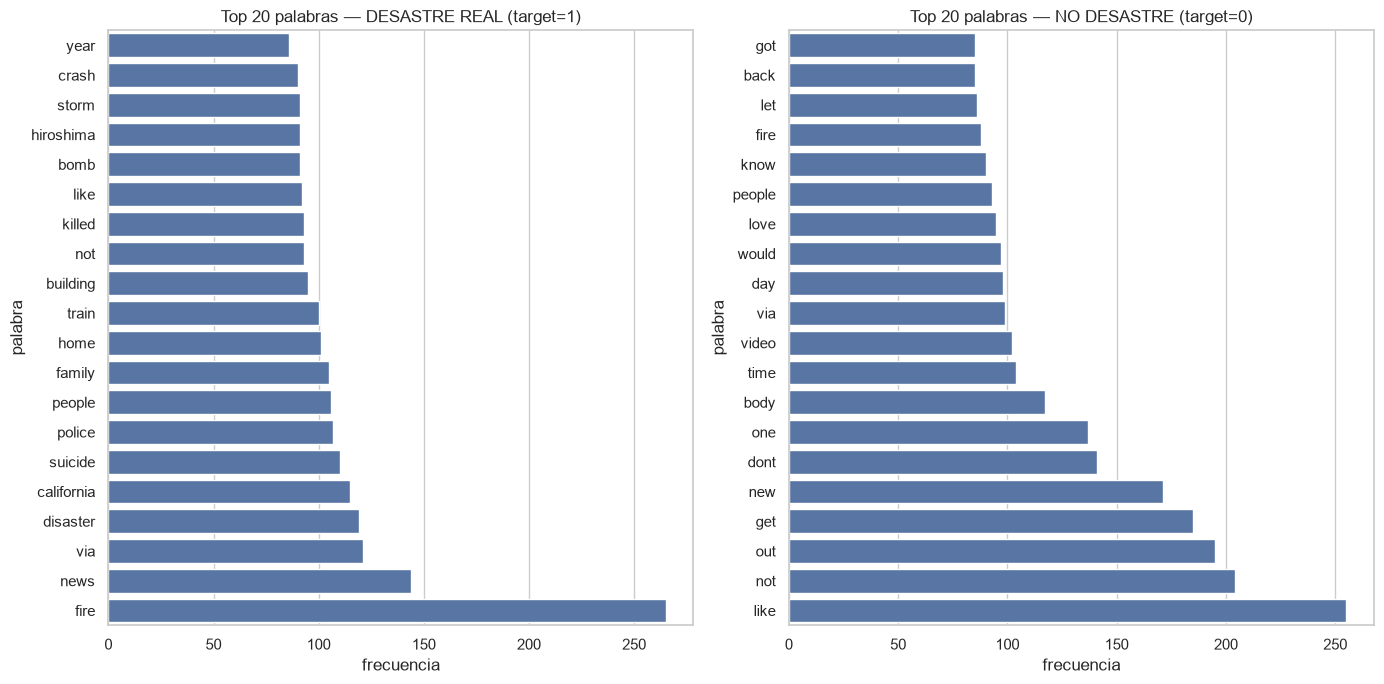

In [39]:
tokens_desastre = [w for t in df.loc[df["target"] == 1, "texto_limpio"] for w in t.split()]
tokens_normal   = [w for t in df.loc[df["target"] == 0, "texto_limpio"] for w in t.split()]

frec_desastre = Counter(tokens_desastre)
frec_normal   = Counter(tokens_normal)

print(f"Vocabulario desastre: {len(frec_desastre)} | tokens: {len(tokens_desastre)}")
print(f"Vocabulario normal  : {len(frec_normal)}   | tokens: {len(tokens_normal)}")

top_d = pd.DataFrame(frec_desastre.most_common(20), columns=["palabra", "frecuencia"])
top_n = pd.DataFrame(frec_normal.most_common(20),   columns=["palabra", "frecuencia"])

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
sns.barplot(data=top_d.sort_values("frecuencia"), y="palabra", x="frecuencia", ax=axes[0])
axes[0].set_title("Top 20 palabras — DESASTRE REAL (target=1)")
sns.barplot(data=top_n.sort_values("frecuencia"), y="palabra", x="frecuencia", ax=axes[1])
axes[1].set_title("Top 20 palabras — NO DESASTRE (target=0)")
guardar_fig("06_top_palabras_por_clase")
plt.show()

In [40]:
set_d, set_n = set(frec_desastre), set(frec_normal)
comunes = set_d & set_n

print(f"Palabras en ambas categorías : {len(comunes)}")
print(f"Exclusivas de desastre       : {len(set_d - set_n)}")
print(f"Exclusivas de no desastre    : {len(set_n - set_d)}")

comunes_top = sorted(comunes, key=lambda w: frec_desastre[w] + frec_normal[w], reverse=True)[:20]
pd.DataFrame({
    "palabra": comunes_top,
    "frec_desastre": [frec_desastre[w] for w in comunes_top],
    "frec_normal":   [frec_normal[w]   for w in comunes_top],
    "razon_d_sobre_n": [round(frec_desastre[w] / max(frec_normal[w], 1), 2) for w in comunes_top],
})

Palabras en ambas categorías : 3444
Exclusivas de desastre       : 3679
Exclusivas de no desastre    : 5800


,palabra,frec_desastre,frec_normal,razon_d_sobre_n
0,fire,265,88,3.01
1,like,92,255,0.36
2,not,93,204,0.46
3,out,76,195,0.39
4,get,70,185,0.38
5,new,56,171,0.33
6,via,121,99,1.22
7,one,70,137,0.51
8,news,144,61,2.36
9,people,106,93,1.14


Los tweets de desastre real usan un vocabulario más concentrado, 7,123 palabras distintas en 29,356 tokens, contra 9,244 en 35,220 de los que no lo son, porque las noticias de desastres reutilizan vocabulario técnico mientras que la conversación casual es más variada.

De las 3,444 palabras presentes en ambas categorías, fire, disaster, police, building y news aparecen entre dos y tres veces más del lado de desastre, mientras que like, get, out, dont y body dominan del otro. El caso de body es el más ambiguo, porque aparece tanto en contextos de víctimas como de ropa y belleza.

In [41]:
vocab = set_d | set_n
N_d, N_n = len(tokens_desastre), len(tokens_normal)
alpha = 1.0
MIN_FREC = 10

filas = []
for w in vocab:
    fd, fn = frec_desastre.get(w, 0), frec_normal.get(w, 0)
    if fd + fn < MIN_FREC:
        continue
    p_d = (fd + alpha) / (N_d + alpha * len(vocab))
    p_n = (fn + alpha) / (N_n + alpha * len(vocab))
    filas.append({"palabra": w, "frec_desastre": fd, "frec_normal": fn,
                  "P(w|desastre)": p_d, "P(w|no_desastre)": p_n,
                  "log_odds": np.log(p_d / p_n)})

discriminantes = pd.DataFrame(filas).sort_values("log_odds", ascending=False)
print("=== Más indicativas de DESASTRE REAL ===")
display(discriminantes.head(20).round(6))
print("=== Más indicativas de NO DESASTRE ===")
display(discriminantes.tail(20).sort_values("log_odds").round(6))

=== Más indicativas de DESASTRE REAL ===


,palabra,frec_desastre,frec_normal,P(w|desastre),P(w|no_desastre),log_odds
294,northern,64,0,0.001537,0.000021,4.304273
1286,legionnaire,62,0,0.001490,0.000021,4.273020
909,debris,50,0,0.001206,0.000021,4.061711
314,migrant,48,0,0.001159,0.000021,4.021706
1101,severe,47,0,0.001135,0.000021,4.001086
53,hiroshima,91,1,0.002176,0.000042,3.958527
833,derailment,41,0,0.000993,0.000021,3.867555
747,investigator,37,0,0.000899,0.000021,3.767471
1322,mosque,36,0,0.000875,0.000021,3.740803
126,detonated,31,0,0.000757,0.000021,3.595621


=== Más indicativas de NO DESASTRE ===


,palabra,frec_desastre,frec_normal,P(w|desastre),P(w|no_desastre),log_odds
399,bag,2,83,0.000071,0.001745,-3.202319
694,ruin,1,39,0.000047,0.000831,-2.865847
445,disney,0,16,0.000024,0.000353,-2.703328
1058,lmao,0,16,0.000024,0.000353,-2.703328
975,bitch,0,15,0.000024,0.000332,-2.642703
191,career,0,15,0.000024,0.000332,-2.642703
485,ebay,1,29,0.000047,0.000623,-2.578165
1342,character,0,14,0.000024,0.000312,-2.578165
1319,electrocute,1,27,0.000047,0.000582,-2.509172
1029,louis,0,12,0.000024,0.000270,-2.435064


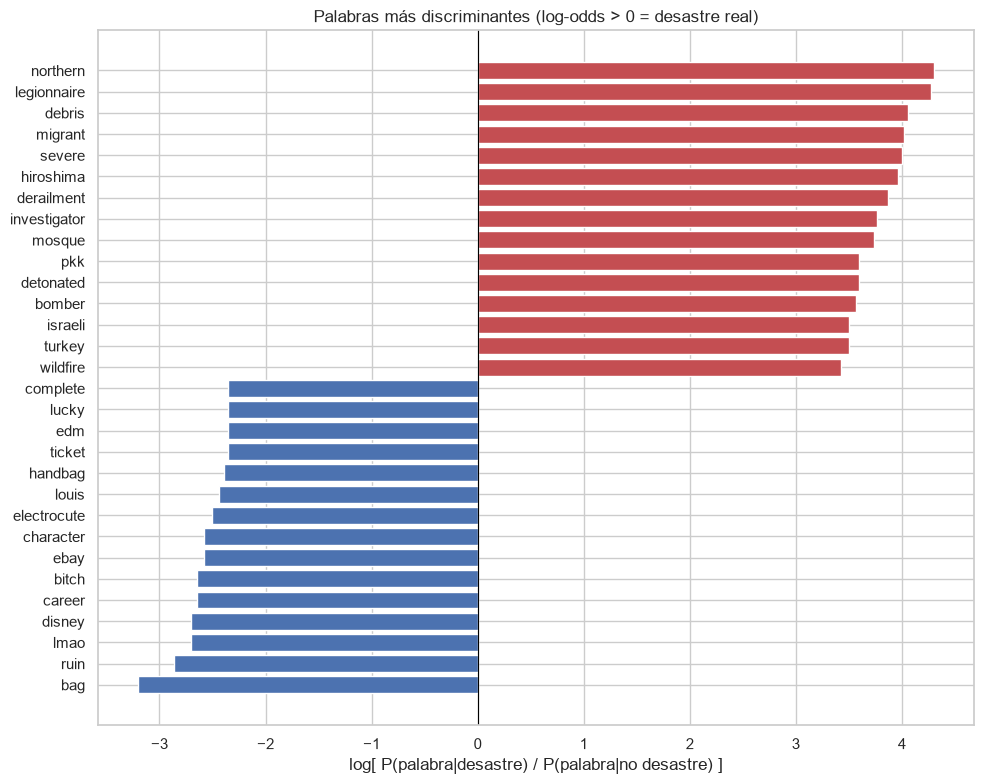

In [42]:
fig, ax = plt.subplots(figsize=(10, 8))
top20 = pd.concat([discriminantes.head(15), discriminantes.tail(15)]).sort_values("log_odds")
colores = ["#c44e52" if v > 0 else "#4c72b0" for v in top20["log_odds"]]
ax.barh(top20["palabra"], top20["log_odds"], color=colores)
ax.set_title("Palabras más discriminantes (log-odds > 0 = desastre real)")
ax.set_xlabel("log[ P(palabra|desastre) / P(palabra|no desastre) ]")
ax.axvline(0, color="black", lw=0.8)
guardar_fig("07_log_odds")
plt.show()

Calculamos el log-odds de cada palabra entre las dos clases con suavizado de Laplace y descartando términos con menos de 10 apariciones, para que una palabra rara no domine el ranking. Del lado de desastre real aparecen northern, california, legionnaire, hiroshima, derailment, mosque y bomber, y del lado opuesto bag, disney, lmao, ebay, handbag, cake y jeb.

La limitación es clara: varios de los términos más discriminantes corresponden a los eventos noticiosos del momento en que se recolectó el dataset y no necesariamente generalizan a desastres futuros.

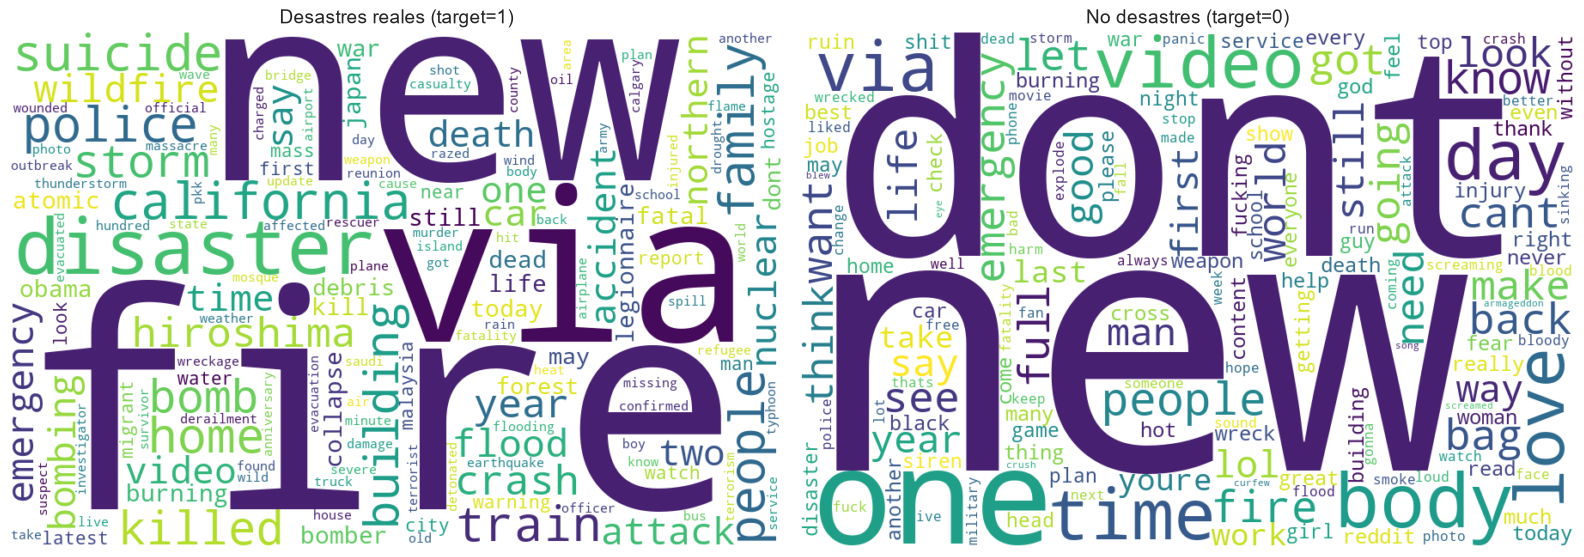

In [43]:
from wordcloud import WordCloud

texto_d = " ".join(tokens_desastre)
texto_n = " ".join(tokens_normal)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, txt, titulo in [(axes[0], texto_d, "Desastres reales (target=1)"),
                        (axes[1], texto_n, "No desastres (target=0)")]:
    wc = WordCloud(width=900, height=600, background_color="white",
                   max_words=150, random_state=RANDOM_STATE, collocations=False).generate(txt)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(titulo, fontsize=14)
guardar_fig("08_nubes_palabras")
plt.show()

La nube de desastre real está dominada por vocabulario noticioso y de emergencia como fire, disaster, california, police, news, killed y storm, mientras que la de no desastre muestra lenguaje coloquial como like, body, love, full y going. Palabras como fire, disaster y emergency aparecen con fuerza en ambas nubes, y son justamente las que hacen difícil el problema porque se usan tanto en sentido literal como figurado.

In [44]:
from sklearn.feature_extraction.text import CountVectorizer

def frecuencias_ngramas(corpus, n, top=20, min_df=3):
    vec = CountVectorizer(ngram_range=(n, n), min_df=min_df)
    X = vec.fit_transform(corpus)
    sumas = np.asarray(X.sum(axis=0)).ravel()
    tabla = (pd.DataFrame({"ngrama": vec.get_feature_names_out(), "frecuencia": sumas})
               .sort_values("frecuencia", ascending=False))
    total = tabla["frecuencia"].sum()
    tabla["probabilidad"] = tabla["frecuencia"] / total
    return tabla.head(top).reset_index(drop=True), len(vec.get_feature_names_out())

for n, nombre in [(2, "BIGRAMAS"), (3, "TRIGRAMAS")]:
    td, n_td = frecuencias_ngramas(df.loc[df["target"] == 1, "texto_limpio"], n)
    tn, n_tn = frecuencias_ngramas(df.loc[df["target"] == 0, "texto_limpio"], n)
    print(f"\n===== {nombre} =====")
    print(f"Distintos (min_df=3) -> desastre: {n_td} | no desastre: {n_tn}")
    print(f"\n-- Top {nombre} en DESASTRE REAL --"); display(td.round(6))
    print(f"-- Top {nombre} en NO DESASTRE --");     display(tn.round(6))


===== BIGRAMAS =====
Distintos (min_df=3) -> desastre: 1187 | no desastre: 884

-- Top BIGRAMAS en DESASTRE REAL --


,ngrama,frecuencia,probabilidad
0,suicide bomber,60,0.007806
1,northern california,41,0.005334
2,oil spill,38,0.004944
3,california wildfire,36,0.004684
4,suicide bombing,34,0.004424
5,bomber detonated,30,0.003903
6,home razed,29,0.003773
7,mass murder,28,0.003643
8,detonated bomb,28,0.003643
9,latest home,28,0.003643


-- Top BIGRAMAS en NO DESASTRE --


,ngrama,frecuencia,probabilidad
0,body bag,48,0.010270
1,cross body,38,0.008130
2,liked video,34,0.007274
3,look like,32,0.006846
4,full read,28,0.005991
5,check out,25,0.005349
6,feel like,25,0.005349
7,body bagging,23,0.004921
8,burning building,22,0.004707
9,quarantine offensive,21,0.004493



===== TRIGRAMAS =====
Distintos (min_df=3) -> desastre: 864 | no desastre: 579

-- Top TRIGRAMAS en DESASTRE REAL --


,ngrama,frecuencia,probabilidad
0,suicide bomber detonated,30,0.005699
1,northern california wildfire,29,0.005509
2,home razed northern,28,0.005319
3,bomber detonated bomb,28,0.005319
4,latest home razed,28,0.005319
5,pkk suicide bomber,28,0.005319
6,razed northern california,27,0.005129
7,old pkk suicide,27,0.005129
8,family affected fatal,26,0.004939
9,family sue legionnaire,26,0.004939


-- Top TRIGRAMAS en NO DESASTRE --


,ngrama,frecuencia,probabilidad
0,cross body bag,23,0.008028
1,reddit quarantine offensive,21,0.007330
2,quarantine offensive content,20,0.006981
3,pick fan army,17,0.005934
4,fall off cliff,16,0.005585
5,china stock market,16,0.005585
6,new content policy,16,0.005585
7,stock market crash,16,0.005585
8,reddits new content,16,0.005585
9,hollywood movie trapped,15,0.005236


In [45]:
vec_bi = CountVectorizer(ngram_range=(2, 2), min_df=5)
X_bi = vec_bi.fit_transform(df["texto_limpio"])
frec_bi = dict(zip(vec_bi.get_feature_names_out(),
                   np.asarray(X_bi.sum(axis=0)).ravel()))
frec_uni = Counter(w for t in df["texto_limpio"] for w in t.split())

cond = []
for bigrama, f in frec_bi.items():
    w1, w2 = bigrama.split()
    cond.append({"bigrama": bigrama, "frec": f, "frec_w1": frec_uni[w1],
                 "P(w2|w1)": f / frec_uni[w1]})

tabla_cond = pd.DataFrame(cond).query("frec >= 10").sort_values("P(w2|w1)", ascending=False)
print("Bigramas con mayor probabilidad condicional P(w2|w1):")
tabla_cond.head(25).round(4)

Bigramas con mayor probabilidad condicional P(w2|w1):


,bigrama,frec,frec_w1,P(w2|w1)
835,trent bridge,11,11,1.0000
22,allows parole,12,12,1.0000
846,twelve feared,14,14,1.0000
161,conclusively confirmed,25,25,1.0000
332,funtenna hijacking,17,17,1.0000
786,subreddits banned,17,17,1.0000
262,exchanging shot,11,11,1.0000
288,faux leather,13,13,1.0000
729,selfimage take,11,11,1.0000
757,spaceship crash,10,10,1.0000


Contando solo n-gramas con al menos 3 apariciones hay 1,187 bigramas distintos en tweets de desastre real contra 884 en los demás, y 864 contra 579 trigramas. Los bigramas de desastre real dan el contexto que buscábamos, ya que suicide bomber, northern california, oil spill y california wildfire son mucho menos ambiguos que cada palabra suelta, mientras que del otro lado body bag es el más frecuente y se usa sobre todo como producto y no en su sentido literal.

También hay bigramas con probabilidad condicional igual a uno, como madhya pradesh o spaceship crash, donde la primera palabra nunca aparece sin la segunda y forman colocaciones fijas. El costo es que el vocabulario se multiplica y la mayoría de esos bigramas aparece tres o cuatro veces, así que comparamos las dos configuraciones con métricas en vez de asumir que más contexto siempre ayuda.

In [46]:
df.to_csv(DATA_DIR / "train_limpio.csv", index=False)
discriminantes.to_csv(DATA_DIR / "palabras_discriminantes.csv", index=False)
print("Guardado: data/train_limpio.csv y data/palabras_discriminantes.csv")

Guardado: data/train_limpio.csv y data/palabras_discriminantes.csv


---
# 3. Modelos de clasificación

Para abordar el contexto probamos TF-IDF con unigramas como línea base, TF-IDF con unigramas y bigramas para capturar contexto local, y la concatenación de la keyword al texto porque el análisis exploratorio la mostró muy informativa.

Comparamos cuatro algoritmos sobre las mismas particiones y elegimos con F1 y no con accuracy, porque las clases están desbalanceadas y no detectar un desastre real cuesta más que levantar una falsa alarma.

In [47]:
from sklearn.base import clone
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

df = pd.read_csv(DATA_DIR / "train_limpio.csv")
df["texto_limpio"] = df["texto_limpio"].fillna("")

df["keyword_limpia"] = df["keyword"].fillna("").str.replace("%20", " ", regex=False)
df["entrada"] = (df["keyword_limpia"] + " " + df["texto_limpio"]).str.strip()

X = df["entrada"]
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print(f"Entrenamiento: {len(X_train)} | Prueba: {len(X_test)}")
print(f"Proporción de target=1 -> train {y_train.mean():.3f} | test {y_test.mean():.3f}")
print(f"\nBaseline (predecir siempre la clase mayoritaria): {max(y.mean(), 1-y.mean()):.4f}")

Entrenamiento: 6090 | Prueba: 1523
Proporción de target=1 -> train 0.430 | test 0.429

Baseline (predecir siempre la clase mayoritaria): 0.5703


In [48]:
modelos = {
    "Regresión Logística": LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE),
    "Naive Bayes Multinomial": MultinomialNB(alpha=1.0),
    "SVM Lineal": LinearSVC(C=1.0, random_state=RANDOM_STATE, max_iter=5000),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
}
configs_ngramas = {"unigramas (1,1)": (1, 1), "uni+bigramas (1,2)": (1, 2)}

resultados = []
modelos_entrenados = {}
for nombre_cfg, rango in configs_ngramas.items():
    for nombre_modelo, clf in modelos.items():
        pipe = Pipeline([
            ("tfidf", TfidfVectorizer(ngram_range=rango, min_df=2, max_df=0.9,
                                      sublinear_tf=True)),
            ("clf", clone(clf)),
        ])
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
        if hasattr(pipe, "predict_proba"):
            scores = pipe.predict_proba(X_test)[:, 1]
        else:
            scores = pipe.decision_function(X_test)

        resultados.append({
            "modelo": nombre_modelo,
            "n_gramas": nombre_cfg,
            "accuracy":  accuracy_score(y_test, pred),
            "precision": precision_score(y_test, pred),
            "recall":    recall_score(y_test, pred),
            "f1":        f1_score(y_test, pred),
            "roc_auc":   roc_auc_score(y_test, scores),
            "n_features": len(pipe.named_steps["tfidf"].get_feature_names_out()),
        })
        modelos_entrenados[f"{nombre_modelo} | {nombre_cfg}"] = pipe

tabla_resultados = (pd.DataFrame(resultados)
                      .sort_values("f1", ascending=False)
                      .reset_index(drop=True))
tabla_resultados.round(4)

,modelo,n_gramas,accuracy,precision,recall,f1,roc_auc,n_features
0,Regresión Logística,"unigramas (1,1)",0.8247,0.8365,0.7355,0.7828,0.8730,4729
1,Naive Bayes Multinomial,"unigramas (1,1)",0.8181,0.8360,0.7171,0.7720,0.8720,4729
2,SVM Lineal,"uni+bigramas (1,2)",0.8083,0.7919,0.7508,0.7708,0.8633,9350
3,SVM Lineal,"unigramas (1,1)",0.8070,0.7885,0.7523,0.7700,0.8622,4729
4,Regresión Logística,"uni+bigramas (1,2)",0.8142,0.8249,0.7202,0.7690,0.8741,9350
5,Naive Bayes Multinomial,"uni+bigramas (1,2)",0.8201,0.8696,0.6835,0.7654,0.8727,9350
6,Random Forest,"unigramas (1,1)",0.8011,0.8106,0.7003,0.7514,0.8551,4729
7,Random Forest,"uni+bigramas (1,2)",0.8017,0.8212,0.6881,0.7488,0.8595,9350


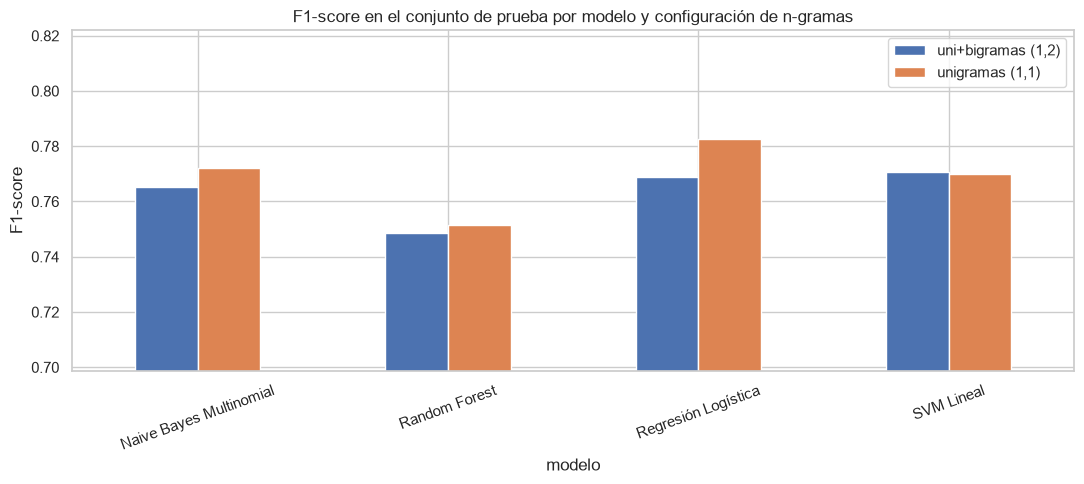

In [49]:
fig, ax = plt.subplots(figsize=(11, 5))
pivot = tabla_resultados.pivot(index="modelo", columns="n_gramas", values="f1")
pivot.plot(kind="bar", ax=ax, rot=20)
ax.set_title("F1-score en el conjunto de prueba por modelo y configuración de n-gramas")
ax.set_ylabel("F1-score")
ax.set_ylim(bottom=max(0, pivot.values.min() - 0.05))
ax.legend(title="")
guardar_fig("09_comparacion_modelos")
plt.show()

In [50]:
mejor_nombre = f"{tabla_resultados.iloc[0]['modelo']} | {tabla_resultados.iloc[0]['n_gramas']}"
mejor_modelo = modelos_entrenados[mejor_nombre]
print(f"Mejor modelo por F1: {mejor_nombre}\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
puntajes = cross_val_score(mejor_modelo, X, y, cv=cv, scoring="f1", n_jobs=-1)
print(f"F1 en validación cruzada (5 folds): {puntajes.mean():.4f} (+/- {puntajes.std():.4f})")
print("Por fold:", np.round(puntajes, 4))

Mejor modelo por F1: Regresión Logística | unigramas (1,1)

F1 en validación cruzada (5 folds): 0.7549 (+/- 0.0139)
Por fold: [0.7692 0.7517 0.7322 0.7517 0.7699]


               precision    recall  f1-score   support

  No desastre     0.8175    0.8918    0.8531       869
Desastre real     0.8365    0.7355    0.7828       654

     accuracy                         0.8247      1523
    macro avg     0.8270    0.8137    0.8179      1523
 weighted avg     0.8257    0.8247    0.8229      1523



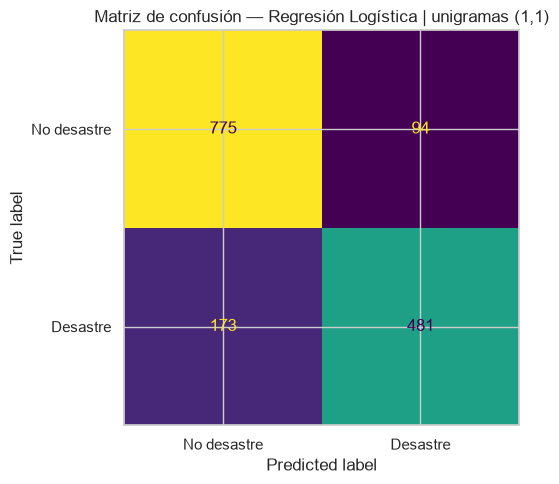

In [51]:
pred = mejor_modelo.predict(X_test)
print(classification_report(y_test, pred, target_names=["No desastre", "Desastre real"], digits=4))

fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                       display_labels=["No desastre", "Desastre"]).plot(ax=ax, colorbar=False)
ax.set_title(f"Matriz de confusión — {mejor_nombre}")
guardar_fig("10_matriz_confusion")
plt.show()

In [52]:
errores = pd.DataFrame({
    "texto": X_test.values,
    "original": df.loc[X_test.index, "text"].values,
    "real": y_test.values,
    "predicho": pred,
})
errores = errores[errores["real"] != errores["predicho"]]
print(f"Errores: {len(errores)} de {len(y_test)} ({len(errores)/len(y_test):.2%})\n")

print("=== FALSOS NEGATIVOS (era desastre real y el modelo dijo que no) ===")
display(errores.query("real == 1")[["original"]].head(8))
print("=== FALSOS POSITIVOS (no era desastre y el modelo dijo que sí) ===")
display(errores.query("real == 0")[["original"]].head(8))

Errores: 267 de 1523 (17.53%)

=== FALSOS NEGATIVOS (era desastre real y el modelo dijo que no) ===


,original
5,Hollywood Movie About Trapped Miners Released in Chile: 'The 33' Hollywood movie about trapped miners starring... ht...
6,Thu Aug 06 2015 01:20:32 GMT+0000 (UTC)\n#millcityio #20150613\ntheramin sirens
7,I can't drown my demons they know how to swim
13,@XHNews We need these plants in the pacific during the cyclone seasons it would help
16,'It looks like a mudslide' poor thing! ?? #greatbritishbakeoff
22,on the flip side I'm at Walmart and there is a bomb and everyone had to evacuate so stay tuned if I blow up or not
26,Bomb head? Explosive decisions dat produced more dead children than dead bodies trapped tween buildings on that day ...
27,I agree with certain cultural appropriation things but honestly if u looked at my house it screams appropriation bc ...


=== FALSOS POSITIVOS (no era desastre y el modelo dijo que sí) ===


,original
0,@TheEconomist Step one: get that mass murderer's portrait off the yuan.
14,if firefighters acted like cops they'd drive around shooting a flamethrower at burning buildings
19,@DrAtomic420 where did you get that pic from where it shows that there is 2 trophies for Outbreak? Or did they photo...
24,@POTUS Maybe we should call Israel and tell them we're sorry are Pres has sold them down the river to annihilation.
34,@TroySlaby22 slicker than an oil spill
64,Look: #I have collapsed #after attempting to munch an endangered species.
78,@AGeekyFangirl14 's things she looks in a significant other:\n1. Beautiful eyes.\n2. Humor.\n3. Farts that creates a...
80,I hope it rains throughout the whole weekend I hope it floods and the portaloos become sentient.


Probamos cuatro algoritmos sobre dos configuraciones de n-gramas con las mismas particiones, 6,090 tweets de entrenamiento y 1,523 de prueba. El mejor por F1 fue la regresión logística con unigramas, con F1 de 0.7828, accuracy de 0.8247 y ROC AUC de 0.8730 sobre 4,729 características, aunque en validación cruzada de cinco particiones el F1 baja a 0.7549.

Los bigramas no mejoraron con estos parámetros: duplican las características de 4,729 a 9,350 y el F1 baja en tres de los cuatro algoritmos. De los 267 errores, la mayoría son casos de lenguaje figurado o sarcástico, donde el vocabulario de desastre aparece en frases que no hablan de ningún desastre.

---
# 4. Selección y ajuste del mejor modelo

La comparación previa dejó tres algoritmos con desempeño parecido y descartó Random Forest, que quedó último en ambas configuraciones. A cada uno le buscamos hiperparámetros con GridSearchCV, optimizando F1 sobre validación cruzada estratificada de cinco particiones y usando solo el conjunto de entrenamiento, con 72 combinaciones repartidas en paralelo entre todos los núcleos.

La rejilla mueve el vectorizador y el clasificador a la vez: rango de n-gramas, frecuencia mínima de documento, fuerza de regularización y peso de las clases.

In [53]:
import time
from sklearn.model_selection import GridSearchCV, cross_val_predict

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def puntajes(modelo, datos):
    if hasattr(modelo, "predict_proba"):
        return modelo.predict_proba(datos)[:, 1]
    return modelo.decision_function(datos)

espacios = {
    "Regresion Logistica": (
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        {"tfidf__ngram_range": [(1, 1), (1, 2)],
         "tfidf__min_df": [1, 2],
         "clf__C": [0.5, 1, 3, 10],
         "clf__class_weight": [None, "balanced"]},
    ),
    "SVM Lineal": (
        LinearSVC(random_state=RANDOM_STATE, max_iter=10000),
        {"tfidf__ngram_range": [(1, 1), (1, 2)],
         "tfidf__min_df": [1, 2],
         "clf__C": [0.1, 0.3, 1.0],
         "clf__class_weight": [None, "balanced"]},
    ),
    "Naive Bayes Multinomial": (
        MultinomialNB(),
        {"tfidf__ngram_range": [(1, 1), (1, 2)],
         "tfidf__min_df": [1, 2],
         "clf__alpha": [0.1, 0.3, 0.5, 1.0]},
    ),
}

filas, busquedas = [], {}
for nombre, (clf, grid) in espacios.items():
    t0 = time.time()
    pipe = Pipeline([("tfidf", TfidfVectorizer(max_df=0.9, sublinear_tf=True)),
                     ("clf", clone(clf))])
    gs = GridSearchCV(pipe, grid, scoring="f1", cv=cv, n_jobs=-1)
    gs.fit(X_train, y_train)
    busquedas[nombre] = gs
    pred = gs.predict(X_test)
    filas.append({
        "modelo": nombre,
        "f1_cv": gs.best_score_,
        "f1_cv_std": gs.cv_results_["std_test_score"][gs.best_index_],
        "f1_test": f1_score(y_test, pred),
        "accuracy_test": accuracy_score(y_test, pred),
        "roc_auc_test": roc_auc_score(y_test, puntajes(gs.best_estimator_, X_test)),
        "da_probabilidad": hasattr(gs.best_estimator_, "predict_proba"),
        "combinaciones": len(gs.cv_results_["params"]),
        "segundos": round(time.time() - t0, 1),
    })
    print(f"{nombre}: F1 en validacion cruzada = {gs.best_score_:.4f}")
    print(f"   mejores parametros: {gs.best_params_}\n")

tabla_busqueda = (pd.DataFrame(filas)
                    .sort_values("f1_cv", ascending=False)
                    .reset_index(drop=True))
tabla_busqueda.round(4)

Regresion Logistica: F1 en validacion cruzada = 0.7536
   mejores parametros: {'clf__C': 1, 'clf__class_weight': 'balanced', 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}



SVM Lineal: F1 en validacion cruzada = 0.7542
   mejores parametros: {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}



Naive Bayes Multinomial: F1 en validacion cruzada = 0.7477
   mejores parametros: {'clf__alpha': 0.3, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}



,modelo,f1_cv,f1_cv_std,f1_test,accuracy_test,roc_auc_test,da_probabilidad,combinaciones,segundos
0,SVM Lineal,0.7542,0.0031,0.7767,0.8089,0.8716,False,24,1.2
1,Regresion Logistica,0.7536,0.0041,0.7731,0.8050,0.8721,True,32,6.3
2,Naive Bayes Multinomial,0.7477,0.0080,0.7770,0.8194,0.8714,True,16,0.8


In [54]:
mejor_f1  = tabla_busqueda.iloc[0]["f1_cv"]
error_est = tabla_busqueda.iloc[0]["f1_cv_std"] / np.sqrt(cv.get_n_splits())
print(f"Mejor F1 en validacion cruzada: {mejor_f1:.4f}  error estandar {error_est:.4f}")

empatados = tabla_busqueda[tabla_busqueda["f1_cv"] >= mejor_f1 - error_est]
print(f"Modelos dentro de un error estandar del mejor: {list(empatados['modelo'])}")

con_prob = empatados[empatados["da_probabilidad"]]
nombre_ganador = (con_prob if len(con_prob) else empatados).iloc[0]["modelo"]
gs_ganador     = busquedas[nombre_ganador]
modelo_ganador = gs_ganador.best_estimator_
print("\nModelo seleccionado:", nombre_ganador)
print("Parametros         :", gs_ganador.best_params_)

Mejor F1 en validacion cruzada: 0.7542  error estandar 0.0014
Modelos dentro de un error estandar del mejor: ['SVM Lineal', 'Regresion Logistica']

Modelo seleccionado: Regresion Logistica
Parametros         : {'clf__C': 1, 'clf__class_weight': 'balanced', 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}


In [55]:
from sklearn.model_selection import RepeatedStratifiedKFold

modelo_base = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 1), min_df=2, max_df=0.9, sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)),
])

cv_rep = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
comparacion_ajuste = []
for etiqueta, modelo in [("configuracion base", modelo_base),
                         ("configuracion ajustada", modelo_ganador)]:
    s = cross_val_score(modelo, X, y, cv=cv_rep, scoring="f1", n_jobs=-1)
    comparacion_ajuste.append({"modelo": etiqueta, "f1_medio": s.mean(),
                               "desv_est": s.std(), "f1_min": s.min(), "f1_max": s.max()})

comparacion_ajuste = pd.DataFrame(comparacion_ajuste)
ganancia = comparacion_ajuste.loc[1, "f1_medio"] - comparacion_ajuste.loc[0, "f1_medio"]
print(f"Ganancia del ajuste en F1 medio sobre 15 particiones: {ganancia:+.4f}")
comparacion_ajuste.round(4)

Ganancia del ajuste en F1 medio sobre 15 particiones: +0.0063


,modelo,f1_medio,desv_est,f1_min,f1_max
0,configuracion base,0.7559,0.0109,0.7322,0.7699
1,configuracion ajustada,0.7622,0.0131,0.7393,0.7847


## Resultado de la búsqueda

Los tres algoritmos quedan empatados dentro del error estándar de 0.0014: SVM lineal con 0.7542 de F1 en validación cruzada, regresión logística con 0.7536 y Naive Bayes con 0.7477. Aplicamos la regla de una desviación estándar y elegimos la regresión logística, que entrega probabilidad en vez de distancia al hiperplano, con unigramas y bigramas, frecuencia mínima de documento igual a 1, C igual a 1 y pesos balanceados.

La búsqueda sí terminó prefiriendo los bigramas, al revés de lo que salía con parámetros por defecto, porque la frecuencia mínima bajó a 1 y el peso balanceado compensa el desbalance. Aun así el ajuste aporta poco, ya que sobre quince particiones el F1 medio sube de 0.7559 a 0.7622, una ganancia de 0.0063 frente a una desviación estándar de 0.013.

In [56]:
from sklearn.metrics import precision_recall_curve, roc_curve, average_precision_score

metodo = "predict_proba" if hasattr(modelo_ganador, "predict_proba") else "decision_function"
oof = cross_val_predict(modelo_ganador, X_train, y_train, cv=cv, method=metodo, n_jobs=-1)
if oof.ndim == 2:
    oof = oof[:, 1]

prec, rec, umbrales = precision_recall_curve(y_train, oof)
f1_por_umbral = 2 * prec * rec / np.maximum(prec + rec, 1e-12)
i_mejor = int(np.argmax(f1_por_umbral[:-1]))
UMBRAL = float(umbrales[i_mejor])
UMBRAL_BASE = 0.5 if metodo == "predict_proba" else 0.0

print(f"\nUmbral por defecto : {UMBRAL_BASE:.4f}")
print(f"Umbral optimizado  : {UMBRAL:.4f}   F1 fuera de muestra {f1_por_umbral[i_mejor]:.4f}")

puntos_test = puntajes(modelo_ganador, X_test)
comparacion_umbral = pd.DataFrame([
    {"umbral": "por defecto", "valor": UMBRAL_BASE},
    {"umbral": "optimizado",  "valor": UMBRAL},
])
for j, u in enumerate([UMBRAL_BASE, UMBRAL]):
    p = (puntos_test >= u).astype(int)
    comparacion_umbral.loc[j, "accuracy"]  = accuracy_score(y_test, p)
    comparacion_umbral.loc[j, "precision"] = precision_score(y_test, p)
    comparacion_umbral.loc[j, "recall"]    = recall_score(y_test, p)
    comparacion_umbral.loc[j, "f1"]        = f1_score(y_test, p)
comparacion_umbral.round(4)


Umbral por defecto : 0.5000
Umbral optimizado  : 0.5015   F1 fuera de muestra 0.7544


,umbral,valor,accuracy,precision,recall,f1
0,por defecto,0.5000,0.8050,0.7725,0.7737,0.7731
1,optimizado,0.5015,0.8063,0.7749,0.7737,0.7743


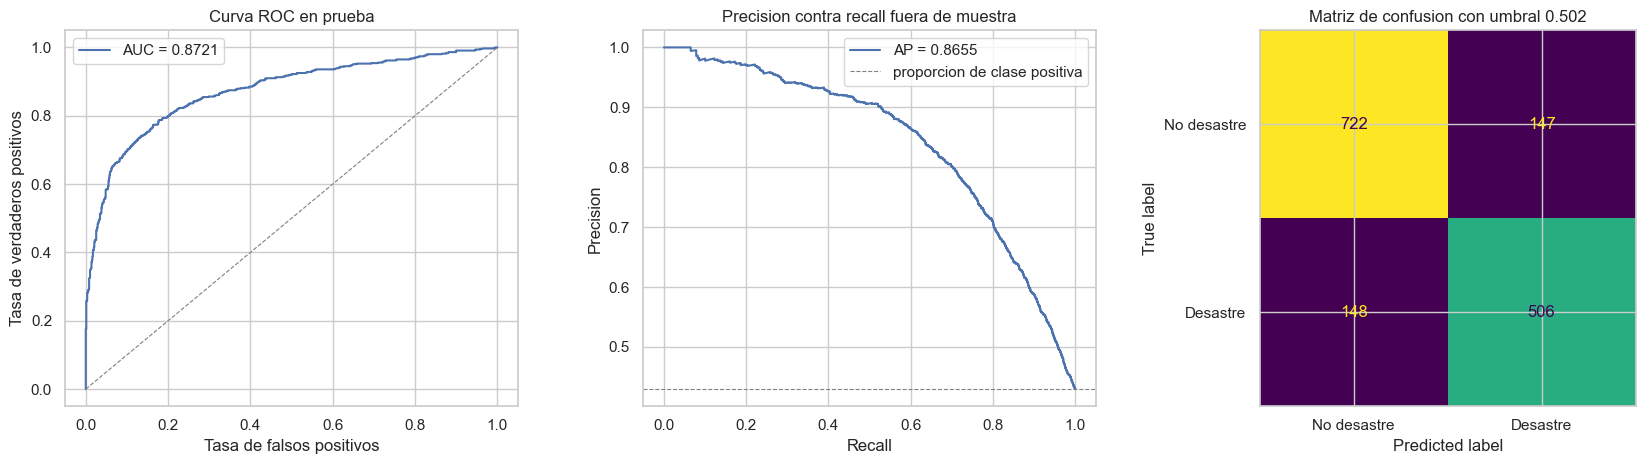

               precision    recall  f1-score   support

  No desastre     0.8299    0.8308    0.8304       869
Desastre real     0.7749    0.7737    0.7743       654

     accuracy                         0.8063      1523
    macro avg     0.8024    0.8023    0.8023      1523
 weighted avg     0.8063    0.8063    0.8063      1523



In [57]:
fpr, tpr, _ = roc_curve(y_test, puntos_test)
auc_test = roc_auc_score(y_test, puntos_test)
ap_test  = average_precision_score(y_test, puntos_test)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

axes[0].plot(fpr, tpr, label=f"AUC = {auc_test:.4f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray", lw=0.8)
axes[0].set_xlabel("Tasa de falsos positivos")
axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].set_title("Curva ROC en prueba")
axes[0].legend()

axes[1].plot(rec, prec, label=f"AP = {ap_test:.4f}")
axes[1].axhline(y_train.mean(), ls="--", color="gray", lw=0.8, label="proporcion de clase positiva")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision contra recall fuera de muestra")
axes[1].legend()

pred_final = (puntos_test >= UMBRAL).astype(int)
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_final),
                       display_labels=["No desastre", "Desastre"]).plot(ax=axes[2], colorbar=False)
axes[2].set_title(f"Matriz de confusion con umbral {UMBRAL:.3f}")

guardar_fig("11_modelo_ajustado")
plt.show()

print(classification_report(y_test, pred_final,
                            target_names=["No desastre", "Desastre real"], digits=4))

Caracteristicas totales: 50921
Bigramas entre las 200 caracteristicas de mayor peso: 7
Bigramas en el vocabulario completo: 39501


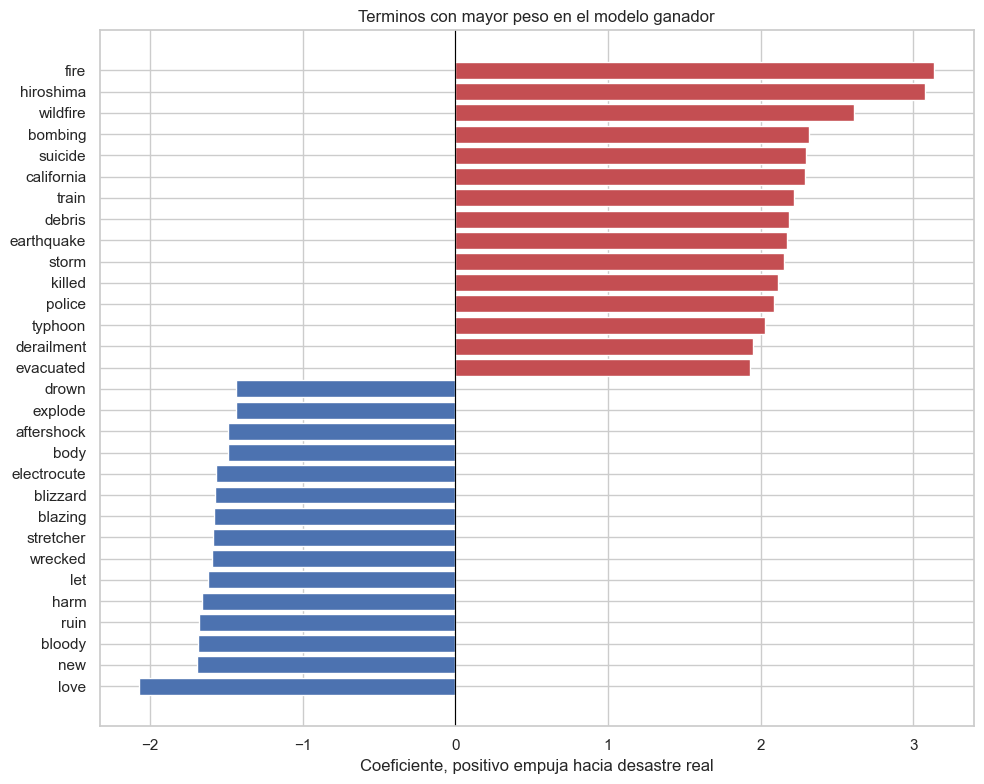

In [58]:
paso_tfidf = modelo_ganador.named_steps["tfidf"]
paso_clf   = modelo_ganador.named_steps["clf"]
terminos   = paso_tfidf.get_feature_names_out()
print("Caracteristicas totales:", len(terminos))

if hasattr(paso_clf, "coef_"):
    pesos = pd.Series(np.ravel(paso_clf.coef_), index=terminos).sort_values()
    top_neg, top_pos = pesos.head(15), pesos.tail(15)

    fuertes = pesos.abs().nlargest(200).index
    n_bigramas = sum(1 for t in fuertes if " " in t)
    print(f"Bigramas entre las 200 caracteristicas de mayor peso: {n_bigramas}")
    print(f"Bigramas en el vocabulario completo: {sum(1 for t in terminos if ' ' in t)}")

    fig, ax = plt.subplots(figsize=(10, 8))
    juntos = pd.concat([top_neg, top_pos])
    ax.barh(juntos.index, juntos.values,
            color=["#4c72b0"] * len(top_neg) + ["#c44e52"] * len(top_pos))
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title("Terminos con mayor peso en el modelo ganador")
    ax.set_xlabel("Coeficiente, positivo empuja hacia desastre real")
    guardar_fig("12_pesos_modelo")
    plt.show()

## Umbral de decisión y desempeño final

El umbral se calibró con predicciones fuera de muestra del entrenamiento, nunca con el de prueba. El valor óptimo es 0.5015, casi idéntico al 0.5 por defecto, y mueve el F1 de prueba de 0.7731 a 0.7743, señal de que el peso balanceado ya había corregido el desbalance. El modelo alcanza accuracy de 0.8063, F1 de 0.7743, precisión de 0.7749, recall de 0.7737 y ROC AUC de 0.8721, muy por encima del piso de 0.5703.

Los términos de mayor peso confirman el análisis de log-odds, con hiroshima, fire, wildfire, bombing, suicide, earthquake y typhoon empujando hacia desastre real, y love, ruin, new, blazing, aftershock, body y bag empujando al contrario. De las 200 características más influyentes solo 7 son bigramas, aunque el vocabulario contiene 39,501, así que el modelo los aprovecha de forma muy selectiva.

In [59]:
import joblib

modelo_final = clone(modelo_ganador)
modelo_final.fit(X, y)

MODELO_DIR = Path("modelo")
MODELO_DIR.mkdir(exist_ok=True)
joblib.dump({"pipeline": modelo_final, "umbral": UMBRAL, "metodo": metodo,
             "nombre": nombre_ganador, "parametros": gs_ganador.best_params_},
            MODELO_DIR / "clasificador_desastres.joblib")

print(f"Modelo final entrenado con {len(X)} tweets")
print("Guardado en modelo/clasificador_desastres.joblib")
print("Caracteristicas del modelo final:",
      len(modelo_final.named_steps["tfidf"].get_feature_names_out()))

Modelo final entrenado con 7613 tweets
Guardado en modelo/clasificador_desastres.joblib
Caracteristicas del modelo final: 60827


---
# 5. Función de clasificación

La función recibe el texto crudo de un tweet y devuelve si se refiere a un desastre real, aplicando internamente el mismo preprocesamiento del entrenamiento. Usa el modelo reentrenado con las 7,613 filas y guardado en disco junto con su umbral, así que se puede usar sin volver a entrenar.

El modelo se entrenó con la keyword concatenada al texto, pero un tweet nuevo no la trae. La función acepta ese argumento como opcional y lo deja vacío por defecto, lo cual funciona porque el término de la keyword casi siempre aparece dentro del propio texto del tweet.

In [60]:
def clasificar_tweet(texto, keyword="", modelo=None, umbral=None, detalle=False):
    """Recibe el texto crudo de un tweet y devuelve si habla de un desastre real."""
    modelo = modelo if modelo is not None else modelo_final
    umbral = umbral if umbral is not None else UMBRAL

    limpio  = limpiar_texto(texto)
    kw      = str(keyword or "").replace("%20", " ").lower().strip()
    entrada = f"{kw} {limpio}".strip()

    punto = float(puntajes(modelo, [entrada])[0])
    etiqueta = int(punto >= umbral)

    if detalle:
        return {
            "texto_original": texto,
            "texto_limpio": limpio,
            "puntaje": round(punto, 4),
            "umbral": round(umbral, 4),
            "prediccion": etiqueta,
            "etiqueta": "Desastre real" if etiqueta else "No desastre",
        }
    return "Desastre real" if etiqueta else "No desastre"

def clasificar_lote(textos, keywords=None):
    keywords = keywords or [""] * len(textos)
    entradas = [f"{str(k or '').lower().strip()} {limpiar_texto(t)}".strip()
                for t, k in zip(textos, keywords)]
    puntos = puntajes(modelo_final, entradas)
    return pd.DataFrame({
        "tweet": textos,
        "puntaje": np.round(puntos, 4),
        "clasificacion": np.where(puntos >= UMBRAL, "Desastre real", "No desastre"),
    })

print(clasificar_tweet("Forest fire near La Ronge Sask. Canada"))
print(clasificar_tweet("My new phone is on fire, this camera is insane"))

Desastre real
No desastre


In [61]:
ejemplos = [
    "BREAKING: 7.1 magnitude earthquake hits Mexico City, buildings collapsed, rescue teams on site",
    "Just watched the new season, that plot twist was a total disaster lol",
    "Evacuation ordered as wildfire spreads through northern California #CAfire http://t.co/abc123",
    "this song is fire !!! @dj_khaled killed it",
    "Typhoon Soudelor death toll rises to 24 in Taiwan and China",
    "I'm drowning in homework, send help",
    "Emergency crews respond to a train derailment carrying hazardous materials near the river",
    "My mom is going to murder me when she sees this grade",
]
clasificar_lote(ejemplos)

,tweet,puntaje,clasificacion
0,"BREAKING: 7.1 magnitude earthquake hits Mexico City, buildings collapsed, rescue teams on site",0.8017,Desastre real
1,"Just watched the new season, that plot twist was a total disaster lol",0.3524,No desastre
2,Evacuation ordered as wildfire spreads through northern California #CAfire http://t.co/abc123,0.9045,Desastre real
3,this song is fire !!! @dj_khaled killed it,0.7843,Desastre real
4,Typhoon Soudelor death toll rises to 24 in Taiwan and China,0.8386,Desastre real
5,"I'm drowning in homework, send help",0.3426,No desastre
6,Emergency crews respond to a train derailment carrying hazardous materials near the river,0.9177,Desastre real
7,My mom is going to murder me when she sees this grade,0.3777,No desastre


In [62]:
display(pd.DataFrame([clasificar_tweet(t, detalle=True) for t in ejemplos[:4]]))

def clasificador_interactivo():
    print("Escriba un tweet y presione enter. Escriba salir para terminar.")
    while True:
        entrada = input("\nTweet > ").strip()
        if entrada.lower() in {"salir", "exit", "quit", ""}:
            print("Fin.")
            break
        r = clasificar_tweet(entrada, detalle=True)
        print(f"  -> {r['etiqueta']} | puntaje {r['puntaje']} | umbral {r['umbral']}")
        print(f"  texto limpio: {r['texto_limpio']}")

MODO_INTERACTIVO = False
if MODO_INTERACTIVO:
    clasificador_interactivo()
else:
    print("Para escribir tweets a mano: poner MODO_INTERACTIVO = True y correr esta celda.")

,texto_original,texto_limpio,puntaje,umbral,prediccion,etiqueta
0,"BREAKING: 7.1 magnitude earthquake hits Mexico City, buildings collapsed, rescue teams on site",breaking magnitude earthquake hit mexico city building collapsed rescue team site,0.8017,0.5015,1,Desastre real
1,"Just watched the new season, that plot twist was a total disaster lol",watched new season plot twist total disaster lol,0.3524,0.5015,0,No desastre
2,Evacuation ordered as wildfire spreads through northern California #CAfire http://t.co/abc123,evacuation ordered wildfire spread northern california cafire,0.9045,0.5015,1,Desastre real
3,this song is fire !!! @dj_khaled killed it,song fire killed,0.7843,0.5015,1,Desastre real


Para escribir tweets a mano: poner MODO_INTERACTIVO = True y correr esta celda.


## Comportamiento de la función

Con ocho tweets escritos a mano la función acierta en siete. Distingue los casos claros de desastre, como el terremoto con edificios colapsados o el descarrilamiento con materiales peligrosos, y también los usos figurados del desastre de una serie o de estar ahogado de tareas.

El único error es revelador: el tweet sobre una canción, que combina fire y killed en sentido elogioso, recibe 0.7843 y se clasifica como desastre real. Es la misma falla del análisis de errores, dos palabras de altísimo peso juntas sin contexto de emergencia, y un modelo de bolsa de palabras no puede resolverla porque la señal está en la construcción de la oración.